# Imports

In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import os
from matplotlib import pyplot as plt
import pandas as pd
from IPython.core.display_functions import clear_output

# Load data

In [59]:
data_folder = "../../data/preprocessed-data"
df_eyewire2_field_level = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_field_level.h5'), key='dataframe')

In [60]:
df_eyewire2_roi_level = pd.read_hdf(os.path.join(data_folder, 'df_eyewire2_roi_level.h5'), key='dataframe')
df_eyewire2_roi_level['date'] = df_eyewire2_roi_level['date'].astype(str)
df_eyewire2_roi_level['exp_num'] = 2
df_eyewire2_roi_level['roi_id'] = df_eyewire2_roi_level['roi_id'].astype(int)
df_eyewire2_roi_level = df_eyewire2_roi_level.set_index(['date', 'exp_num', 'field', 'roi_id'])
df_eyewire2_roi_level.head()

experimenter  raw_id region    cond1  \
date       exp_num field roi_id                                        
2018-10-11 2       GCL0  1            Franke       1     RR  control   
                         2            Franke       1     RR  control   
                         3            Franke       1     RR  control   
                         4            Franke       1     RR  control   
                         5            Franke       1     RR  control   

                                 ch0_name  ch1_name   chirp    cond2  \
date       exp_num field roi_id                                        
2018-10-11 2       GCL0  1       wDataCh0  wDataCh1  gChirp  control   
                         2       wDataCh0  wDataCh1  gChirp  control   
                         3       wDataCh0  wDataCh1  gChirp  control   
                         4       wDataCh0  wDataCh1  gChirp  control   
                         5       wDataCh0  wDataCh1  gChirp  control   

                                 preprocess_id        bar  ... mc_trace_dt  \
date       exp_num field roi_id                            ...               
2018-10-11 2       GCL0  1                   1  movingbar  ...       0.128   
                         2                   1  movingbar  ...       0.128   
                         3                   1  movingbar  ...       0.128   
                         4                   1  movingbar  ...       0.128   
                         5                   1  movingbar  ...       0.128   

                                                                   mc_triggertimes  \
date       exp_num field roi_id                                                      
2018-10-11 2       GCL0  1       [16.126, 21.126, 26.13, 31.134, 36.14, 41.354,...   
                         2       [16.126, 21.126, 26.13, 31.134, 36.14, 41.354,...   
                         3       [16.126, 21.126, 26.13, 31.134, 36.14, 41.354,...   
                         4       [16.126, 21.126, 26.13, 31.134, 36.14, 41.354,...   
                         5       [16.126, 21.126, 26.13, 31.134, 36.14, 41.354,...   

                                cluster_id  group_id supergroup prob_cluster  \
date       exp_num field roi_id                                                
2018-10-11 2       GCL0  1              18        12     ON-OFF     0.804667   
                         2              51        34        dAC     0.605752   
                         3              68        42        dAC     0.772927   
                         4              74        46        dAC     0.488712   
                         5              38        28    Slow ON     0.580714   

                                prob_group prob_supergroup  prob_class  \
date       exp_num field roi_id                                          
2018-10-11 2       GCL0  1        0.819760        0.832646    0.913740   
                         2        0.615440        0.702638    0.702638   
                         3        0.790771        0.927322    0.927322   
                         4        0.494132        0.803859    0.803859   
                         5        0.581366        0.590559    0.629739   

                                                                 probs_per_cluster  
date       exp_num field roi_id                                                     
2018-10-11 2       GCL0  1       [0.0020822615335256726, 0.0032838992937911002,...  
                         2       [0.003336756586838654, 0.008818983121221289, 0...  
                         3       [0.0017071109567420337, 0.0016375104799094017,...  
                         4       [0.0028589256378742686, 0.003341772704406851, ...  
                         5       [0.0012246466912174362, 0.0011384551512382875,...  

[5 rows x 64 columns]

In [61]:
morph_folder = "../../data/morphological-data"
morph_spreadsheet_filename = "Eyewire II Proofread Cells Master List - All Cells (WIP) 2025-09-03.csv"

morph_df = pd.read_csv(os.path.join(os.path.join(morph_folder, morph_spreadsheet_filename)), dtype=str)
print(morph_df.shape)
morph_df.head()

(8893, 41)


,Index,Nuc Coords,Soma Coords,Cell Type (deprecated),611 Proofreader,Proofreader 2,Status,AIS annotated?,Final Link,Final NucID,...,Index for sanity check,Index ok?,updated?,Index OK?,Index for sanity check.1,Updated Nuc ID (Sept 2),Updated Seg ID (Sept 2),Cell Requires Review (DO NOT use Updated IDs for those cells),Review complete,Review notes
0,A4,NaN,NaN,OFF-SAC,Roden Rey,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,A4,ok,no soma coords,ok,A4,NaN,NaN,FALSE,NaN,NaN
1,A5,NaN,NaN,OFF-SAC,Christine,NaN,Complete (cut off),NaN,https://spelunker.cave-explorer.org/#!middleau...,NaN,...,A5,ok,no soma coords,ok,A5,NaN,NaN,FALSE,NaN,NaN
2,A6,"35877, 25970, 1747","35799, 26155, 1578",OFF-SAC,Christine,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940555518380,...,A6,ok,UPDATED,ok,A6,720575940555518380,720575940556408295,FALSE,NaN,NaN
3,A7,"63573, 49070, 1720","63537, 49048, 1697",OFF-SAC,April Grace,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940545056597,...,A7,ok,same,ok,A7,720575940545056597,720575940572159335,FALSE,NaN,NaN
4,A11,"50561, 64354, 1734","50520, 64370, 1656",OFF-SAC,Roden Rey,NaN,Complete,NaN,https://spelunker.cave-explorer.org/#!middleau...,720575940544186175,...,A11,ok,same,ok,A11,720575940544186175,720575940563309953,FALSE,NaN,NaN


In [62]:
mapping_spreadsheet_filename = "roi_mapping_2p_to_em.csv"

mapping_df = pd.read_csv(os.path.join(os.path.join(morph_folder, mapping_spreadsheet_filename)), dtype=str)
mapping_df['exp_num'] = 2
mapping_df['roi_id'] = mapping_df['roi_id'].astype(int)
mapping_df = mapping_df.set_index(['date', 'exp_num', 'field', 'roi_id'])
print(mapping_df.shape)
mapping_df.head()

(380, 2)


Updated Seg ID (Sept 2)  \
date       exp_num field roi_id                           
2018-10-11 2       GCL0  1           720575940550529705   
                         2           720575940568652126   
                         3           720575940572885792   
                         4           720575940566222700   
                         5           720575940577371948   

                                Updated Nuc ID (Sept 2)  
date       exp_num field roi_id                          
2018-10-11 2       GCL0  1           720575940577751704  
                         2           720575940534317101  
                         3           720575940554891618  
                         4           720575940554657378  
                         5           720575940571117757

In [63]:
nuc_col = 'Updated Nuc ID (Sept 2)'

assert nuc_col in morph_df.columns, f"Column '{nuc_col}' not found in morph_df"
assert nuc_col in mapping_df.columns, f"Column '{nuc_col}' not found in mapping_df"

df = df_eyewire2_roi_level.join(mapping_df)
df = df.reset_index().set_index(nuc_col)

morph_df_ = morph_df[morph_df[nuc_col].notna()].set_index(nuc_col)
morph_df_ = morph_df_[~morph_df_.index.duplicated(keep='first')]
df = pd.merge(df, morph_df_, left_index=True, right_index=True, how='inner').reset_index()
df['qfilt'] = (df['bar_qidx'] > 0.6) | (df['chirp_qidx'] > 0.45)

print(list(df.columns))
print(df.shape)
df.head()

['Updated Nuc ID (Sept 2)', 'date', 'exp_num', 'field', 'roi_id', 'experimenter', 'raw_id', 'region', 'cond1', 'ch0_name', 'ch1_name', 'chirp', 'cond2', 'preprocess_id', 'bar', 'mc', 'chirp_stim_name', 'bar_stim_name', 'classifier_id', 'genline', 'animgender', 'eye', 'setupid', 'prepwmorient', 'nxpix', 'nypix', 'pixel_size_um', 'field_ventral_dorsal_pos_um', 'field_temporal_nasal_pos_um', 'ch0_average', 'ch1_average', 'roi_size_um2', 'roi_dia_um', 'ventral_dorsal_pos_um', 'temporal_nasal_pos_um', 'chirp_qidx', 'chirp_pres_qidx', 'chirp_average_norm', 'chirp_average_dt', 'chirp_snippets', 'chirp_snippets_t0', 'chirp_snippets_dt', 'chirp_triggertimes_snippets', 'bar_ds_index', 'bar_ds_pvalue', 'bar_pref_dir', 'bar_os_index', 'bar_os_pvalue', 'bar_pref_or', 'bar_qidx', 'bar_dir_component', 'bar_time_component', 'bar_pres_qidx', 'bar_snippets', 'bar_snippets_t0', 'bar_snippets_dt', 'bar_triggertimes_snippets', 'mc_trace', 'mc_trace_t0', 'mc_trace_dt', 'mc_triggertimes', 'cluster_id', 'grou

,Updated Nuc ID (Sept 2),date,exp_num,field,roi_id,experimenter,raw_id,region,cond1,ch0_name,...,Index for sanity check,Index ok?,updated?,Index OK?,Index for sanity check.1,Updated Seg ID (Sept 2)_y,Cell Requires Review (DO NOT use Updated IDs for those cells),Review complete,Review notes,qfilt
0,720575940577751704,2018-10-11,2,GCL0,1,Franke,1,RR,control,wDataCh0,...,D1,ok,UPDATED,ok,D1,720575940550529705,FALSE,NaN,NaN,False
1,720575940534317101,2018-10-11,2,GCL0,2,Franke,1,RR,control,wDataCh0,...,D2,ok,same,ok,D2,720575940568652126,FALSE,NaN,NaN,True
2,720575940554891618,2018-10-11,2,GCL0,3,Franke,1,RR,control,wDataCh0,...,B94,ok,same,ok,B94,720575940572885792,FALSE,NaN,NaN,True
3,720575940554657378,2018-10-11,2,GCL0,4,Franke,1,RR,control,wDataCh0,...,D4,ok,UPDATED,ok,D4,720575940566222700,FALSE,NaN,NaN,True
4,720575940571117757,2018-10-11,2,GCL0,5,Franke,1,RR,control,wDataCh0,...,D5,ok,same,ok,D5,720575940577371948,FALSE,NaN,NaN,True


# Plot data

In [64]:
from eyewire2_functional_analysis.plot_dataframe import plot_df_chirp_and_bar

import numpy as np
import seaborn as sns

In [65]:
def plot_mean_and_sd(ax, traces, time, color='black', alt_color='dimgray', facealpha=0.2, offset=0.0):

    if traces.shape[0] <= 2:
        ax.plot(time, traces[0] - np.mean(traces[0]) + offset, color=color)
        if len(traces) == 2:
            ax.plot(time, traces[1] - np.mean(traces[1]) + offset, color=alt_color)
    else:
        mu = np.mean(traces, axis=0)
        mu = mu - np.mean(mu) + offset
        sd = np.std(traces, axis=0)

        ax.plot(time, mu, color=color)
        ax.fill_between(time, mu - sd, mu + sd, color=color, alpha=facealpha)

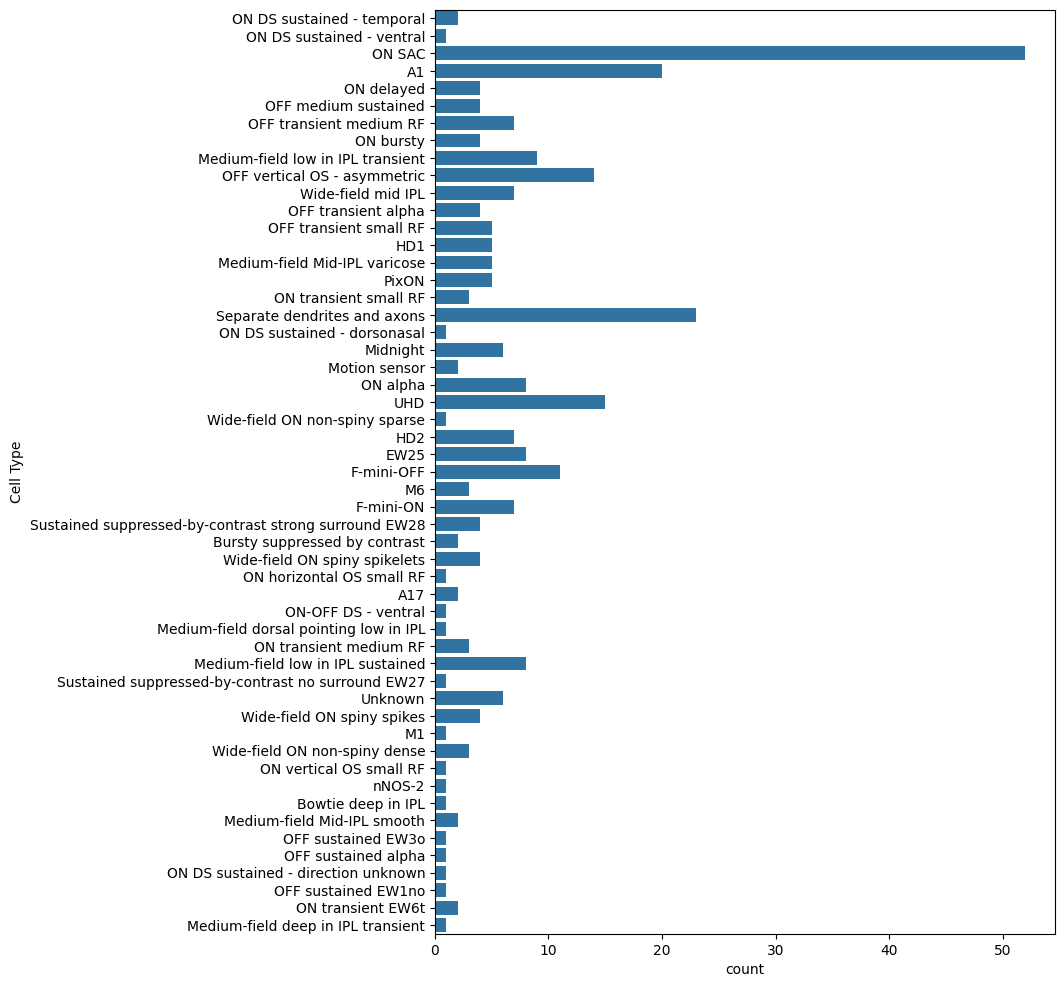

In [66]:
fig, ax = plt.subplots(1, 1 , figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

In [ ]:
fig_dir = 'figures/adaptation_by_type'
os.makedirs(fig_dir, exist_ok=True)

for cell_type, df_group in df.groupby('Cell Type'):
    clear_output()

    fig, axs = plt.subplots(1, 2, figsize=(7, 1 + 0.8 * len(df_group.groupby('field'))),
                            width_ratios=(4, 2), sharey=True)

    fig.suptitle(cell_type)

    sns.despine()

    offset = -2.0
    ax_chirp = axs[0]
    ax_bar = axs[1]

    yticks = []
    yticklabels = []

    for i, (field, df_plot) in enumerate(df_group.groupby('field')):
        t_chirp = np.arange(df_plot.chirp_average_norm.iloc[0].size) * df_plot.chirp_average_dt.iloc[0]
        t_bar = np.arange(df_plot.bar_time_component.iloc[0].size) * df_plot.bar_snippets_dt.iloc[0]

        chirps = np.vstack(df_plot.chirp_average_norm)
        bars = np.vstack(df_plot.bar_time_component)

        plot_mean_and_sd(ax=ax_chirp, traces=chirps, time=t_chirp, offset=i*offset, color='black', facealpha=0.2)
        plot_mean_and_sd(ax=ax_bar, traces=bars, time=t_bar, offset=i*offset, color='black', facealpha=0.2)

        yticks.append(i*offset)
        yticklabels.append(f"{field}\nn={df_plot.shape[0]}")

    axs[0].set_yticks(yticks)
    axs[0].set_yticklabels(yticklabels)
    for ax in axs:
        ax.set_xlabel('Time (s)')

    plt.tight_layout()
    plt.savefig(os.path.join(fig_dir, f'response_adaptation_{cell_type}.pdf'))
    plt.close(fig)